In [15]:
import numpy as np
import matplotlib.pyplot as plt

# TF-IDF Implementation

TF-IDF is a numerical statistic used to reflect how important a word is to a document in a corpus.
It is the product of two components:
- **TF (Term Frequency):** How often a word appears in a document.
- **IDF (Inverse Document Frequency):** How rare the word is across all documents.

Words that appear frequently in one document but rarely across the corpus receive high TF-IDF scores.

## Text Preprocessing

Before computing scores, we normalize text by lowercasing and tokenizing (splitting into words).
This ensures that "Dog" and "dog" are treated as the same word.

In [4]:
def preprocess(text):
    """Lowercase and tokenize a string into a list of words."""
    return text.lower().split()

## 1. Term Frequency (TF)

Term Frequency measures how often a word appears in a document.
There are several common variants:

| Variant | Formula | Notes |
|---|---|---|
| Normalized | count / total words | Most common; accounts for document length |
| Boolean | 1 if present, else 0 | Ignores frequency entirely |
| Raw count | count | Simple but biased toward longer documents |
| Log-scaled | log(1 + count) | Dampens the effect of very high counts |

In [5]:
def term_frequency(word, document):
    """Normalized TF: word count divided by total number of words in the document."""
    return document.count(word) / len(document)


def tf_boolean(word, document):
    """Boolean TF: 1 if the word is present in the document, 0 otherwise."""
    return int(word in document)


def tf_summation(word, document):
    """Raw count TF: the number of times the word appears in the document."""
    return document.count(word)


def tf_log_scaled(word, document):
    """Log-scaled TF: log10(1 + count), dampens the effect of very frequent words."""
    return np.log10(1 + document.count(word))

In [6]:
document = preprocess("My dog is the best dog that ever was a pet dog")

for word in ["dog", "pet", "cat"]:
    print(f"'{word}':")
    print(f"  normalized : {term_frequency(word, document):.4f}")
    print(f"  boolean    : {tf_boolean(word, document)}")
    print(f"  raw count  : {tf_summation(word, document)}")
    print(f"  log-scaled : {tf_log_scaled(word, document):.4f}")

'dog':
  normalized : 0.2500
  boolean    : 1
  raw count  : 3
  log-scaled : 0.6021
'pet':
  normalized : 0.0833
  boolean    : 1
  raw count  : 1
  log-scaled : 0.3010
'cat':
  normalized : 0.0000
  boolean    : 0
  raw count  : 0
  log-scaled : 0.0000


## 2. Inverse Document Frequency (IDF)

IDF penalizes words that appear in many documents (e.g., "the", "a") and rewards rare words.

Two common variants:
- **Standard IDF:** `log(N / df)` — can produce errors if the word is absent from the corpus.
- **Smoothed IDF (scikit-learn style):** `log((N+1) / (df+1)) + 1` — avoids division by zero and keeps non-zero scores for all words.

In [7]:
def idf_standard(word, corpus):
    """Standard IDF: log10(N / df). Returns 0 if the word is not in any document."""
    n_docs = len(corpus)
    n_docs_with_word = sum(1 for doc in corpus if word in doc)
    if n_docs_with_word == 0:
        return 0
    return np.log10(n_docs / n_docs_with_word)


def idf_smoothed(word, corpus):
    """Smoothed IDF (scikit-learn variant): log10((N+1) / (df+1)) + 1.
    Avoids division by zero and ensures all words have a positive IDF.
    """
    n_docs = len(corpus) + 1
    n_docs_with_word = sum(1 for doc in corpus if word in doc) + 1
    return np.log10(n_docs / n_docs_with_word) + 1

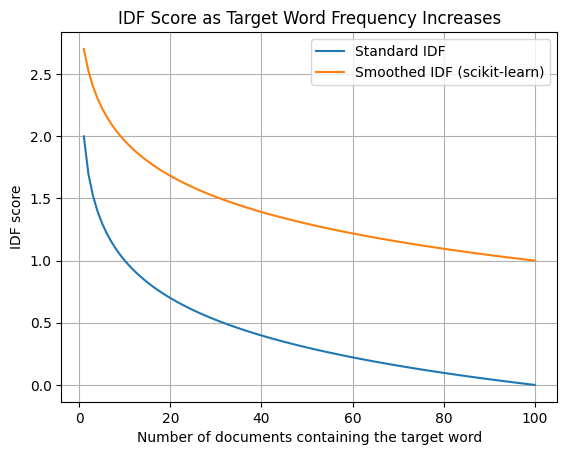

In [8]:
# Visualize how IDF scores change as a target word appears in more documents
dummy_corpus = [["other"] for _ in range(100)]
standard_scores = []
smoothed_scores = []

for i in range(100):
    dummy_corpus[i][0] = "target"
    standard_scores.append(idf_standard("target", dummy_corpus))
    smoothed_scores.append(idf_smoothed("target", dummy_corpus))

plt.plot(range(1, 101), standard_scores, label="Standard IDF")
plt.plot(range(1, 101), smoothed_scores, label="Smoothed IDF (scikit-learn)")
plt.legend()
plt.xlabel("Number of documents containing the target word")
plt.ylabel("IDF score")
plt.title("IDF Score as Target Word Frequency Increases")
plt.grid(True)
plt.show()

## 3. TF-IDF Score

The TF-IDF score for a word in a document is simply:

```
tf_idf(word, document, corpus) = TF(word, document) × IDF(word, corpus)
```

We use the **smoothed IDF** to avoid division-by-zero issues.

In [9]:
def tf_idf(word, document, corpus):
    """Compute the TF-IDF score for a word in a document given the full corpus."""
    return term_frequency(word, document) * idf_smoothed(word, corpus)

In [10]:
corpus_raw = [
    "My dog can play fetch really well",
    "I had a dog that didn't really look like a dog but was a dog",
    "dog bunny cat bunny rooster dog pig goat horse dog dog cat cow sealion bird pigeon penguins and whales and treasure chests and what other random items can go into this long document I wonder",
    "I have a cat",
    "I have a goat",
    "Why is everyone talking about their pets",
    "I have a zebra",
    "You don't have a zebra Timmy",
]
corpus = [preprocess(doc) for doc in corpus_raw]

target_word = "dog"
print(f"TF-IDF scores for the word '{target_word}':\n")
for i, document in enumerate(corpus):
    score = tf_idf(target_word, document, corpus)
    print(f"  Doc {i}: {corpus_raw[i][:55]!r}")
    print(f"          tf={term_frequency(target_word, document):.4f}  "
          f"idf={idf_smoothed(target_word, corpus):.4f}  "
          f"tf-idf={score:.4f}")

TF-IDF scores for the word 'dog':

  Doc 0: 'My dog can play fetch really well'
          tf=0.1429  idf=1.3522  tf-idf=0.1932
  Doc 1: "I had a dog that didn't really look like a dog but was "
          tf=0.2000  idf=1.3522  tf-idf=0.2704
  Doc 2: 'dog bunny cat bunny rooster dog pig goat horse dog dog '
          tf=0.1143  idf=1.3522  tf-idf=0.1545
  Doc 3: 'I have a cat'
          tf=0.0000  idf=1.3522  tf-idf=0.0000
  Doc 4: 'I have a goat'
          tf=0.0000  idf=1.3522  tf-idf=0.0000
  Doc 5: 'Why is everyone talking about their pets'
          tf=0.0000  idf=1.3522  tf-idf=0.0000
  Doc 6: 'I have a zebra'
          tf=0.0000  idf=1.3522  tf-idf=0.0000
  Doc 7: "You don't have a zebra Timmy"
          tf=0.0000  idf=1.3522  tf-idf=0.0000


## 4. TF-IDF Vectors

To compare documents against a query, we represent each document as a **vector** where each dimension corresponds to a unique word in the corpus vocabulary.
The value at each position is the TF-IDF score of that word for the document.
Words absent from a document get a score of 0.

In [11]:
def build_tfidf_matrix(corpus):
    """Build TF-IDF vectors for every document in the corpus.

    Returns:
        matrix       : list of TF-IDF vectors (one per document)
        word_list    : ordered list of vocabulary words
        word_to_index: mapping from word to its position in the vector
    """
    # Preserve insertion order while deduplicating
    word_list = list(dict.fromkeys(word for doc in corpus for word in doc))
    word_to_index = {word: i for i, word in enumerate(word_list)}

    matrix = []
    for doc in corpus:
        vector = [0.0] * len(word_list)
        for word in doc:
            vector[word_to_index[word]] = tf_idf(word, doc, corpus)
        matrix.append(vector)

    return matrix, word_list, word_to_index


tfidf_matrix, word_list, word_to_index = build_tfidf_matrix(corpus)

In [12]:
# Inspect the TF-IDF vector for document 1
doc_index = 1
print(f"Document {doc_index}: {corpus_raw[doc_index]!r}\n")
print("Non-zero TF-IDF scores:")
for word, score in zip(word_list, tfidf_matrix[doc_index]):
    if score > 0:
        print(f"  {word:15s}: {score:.4f}")

Document 1: "I had a dog that didn't really look like a dog but was a dog"

Non-zero TF-IDF scores:
  dog            : 0.2704
  really         : 0.0985
  i              : 0.0784
  had            : 0.1102
  a              : 0.2352
  that           : 0.1102
  didn't         : 0.1102
  look           : 0.1102
  like           : 0.1102
  but            : 0.1102
  was            : 0.1102


## 5. Document Search

To find the most relevant document for a query:
1. Preprocess the query into keywords.
2. For each document, sum the TF-IDF scores of the query keywords.
3. Rank documents by their total score.

In [13]:
def search(query, tfidf_matrix, word_to_index, corpus_raw, top_k=3):
    """Score and rank documents by TF-IDF relevance to a query.

    Args:
        query        : raw query string
        tfidf_matrix : list of TF-IDF vectors (from build_tfidf_matrix)
        word_to_index: vocabulary index mapping
        corpus_raw   : original (unprocessed) document strings for display
        top_k        : number of top results to return

    Returns:
        List of (score, document) tuples ranked highest to lowest.
    """
    query_words = preprocess(query)

    scores = [
        sum(
            doc_vector[word_to_index[word]]
            for word in query_words
            if word in word_to_index
        )
        for doc_vector in tfidf_matrix
    ]

    ranked = sorted(
        zip(scores, corpus_raw),
        key=lambda x: x[0],
        reverse=True,
    )
    return ranked[:top_k]

In [14]:
query = "document about a dog"
results = search(query, tfidf_matrix, word_to_index, corpus_raw)

print(f"Query: {query!r}\n")
print("Top results:")
for rank, (score, doc) in enumerate(results, start=1):
    print(f"  {rank}. (score={score:.4f}) {doc!r}")

Query: 'document about a dog'

Top results:
  1. (score=0.5057) "I had a dog that didn't really look like a dog but was a dog"
  2. (score=0.2940) 'I have a cat'
  3. (score=0.2940) 'I have a goat'
